# 12. EVENT LEVEL RESULTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

segments = pd.read_csv("RESULTS/SEGMENTS_MAIN_MODEL.csv")
results = pd.read_csv("RESULTS/RESULTS_MAIN_MODEL.csv")
false_positives = pd.read_csv("RESULTS/FALSE_POSITIVES_MAIN_MODEL.csv")
events = pd.read_csv("RESULTS/EVENTS_MAIN_MODEL.csv")
seizure_annotations = pd.read_csv('seizure_annotations.csv')


In [3]:
# ----------------------------
# Helper functions
# ----------------------------
def pooled_metrics(df):
    tp = df["tp"].sum()
    fp = df["fp"].sum()
    fn = df["fn"].sum()

    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    precision  = tp / (tp + fp) if (tp + fp) else float("nan")
    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if (precision + sensitivity)
        else float("nan")
    )

    return tp, fp, fn, sensitivity, precision, f1


def median_patient_metrics(df):
    patient_metrics = (
        df.groupby("patient")[[
            "seg_sensitivity",
            "seg_precision",
            "seg_f1"
        ]]
        .median()
    )

    return (
        patient_metrics["seg_sensitivity"].median(),
        patient_metrics["seg_precision"].median(),
        patient_metrics["seg_f1"].median(),
    )



In [4]:
# ==========================================================
# Segment-level pooled metrics
# ==========================================================
tp_s, fp_s, fn_s, sens_s, prec_s, f1_s = pooled_metrics(segments)


# ==========================================================
# Event-level pooled metrics
# ==========================================================
tp_e = events["detected"].sum()
fn_e = (events["detected"] == 0).sum()
fp_e = len(false_positives)   # each row = false alarm event

sens_e = tp_e / (tp_e + fn_e)
prec_e = tp_e / (tp_e + fp_e)
f1_e = 2 * prec_e * sens_e / (prec_e + sens_e)


# ==========================================================
# Combined table
# ==========================================================
comparison = pd.DataFrame({
    "Level": ["Segment", "Event"],
    "Sensitivity": [sens_s, sens_e],
    "Precision": [prec_s, prec_e],
    "F1": [f1_s, f1_e]
})

comparison.round(3)

,Level,Sensitivity,Precision,F1
0,Segment,0.437,0.128,0.198
1,Event,0.735,0.146,0.244


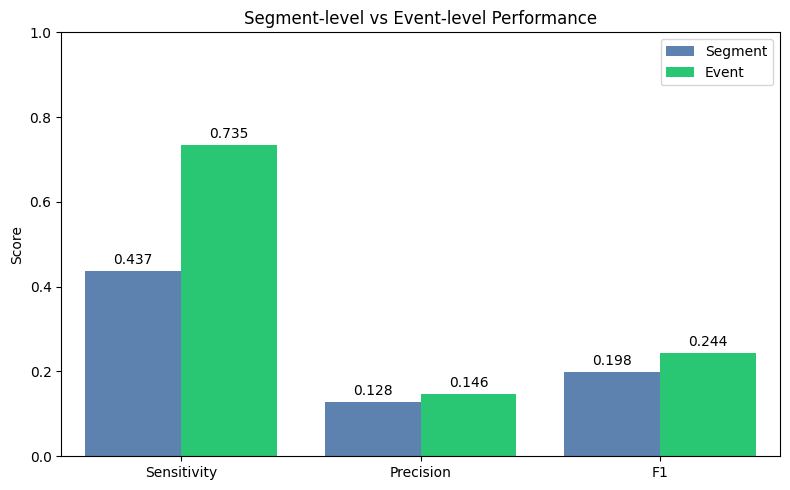

In [5]:
# -----------------------------------
# Colors
# -----------------------------------
# GREEN = "#57e169"
# YELLOW = "#ffd56e"
# BLUE = "#52b6ff"

GREEN = "#0fe071"
YELLOW = "#f4c542"
BLUE = "#4f81bd"


# ==========================================================
# Plot comparison with values
# ==========================================================
plot_df = comparison.melt(
    id_vars="Level",
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=plot_df,
    x="Metric",
    y="Value",
    hue="Level",
    palette=[BLUE, GREEN]   # Segment, Event
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.title("Segment-level vs Event-level Performance")

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.3f}" for v in container.datavalues],
        padding=3,
        fontsize=10
    )

plt.legend(title="")
plt.tight_layout()
plt.show()

## Event Per Patient Table

In [6]:
# ==========================================================
# Per-patient event-level metrics
# ==========================================================

# Seizure detection metrics
patient_events = (
    events.groupby("patient")
    .agg(
        n_seizures=("detected", "size"),
        TP=("detected", "sum"),
    )
)

patient_events["FN"] = (
    patient_events["n_seizures"] - patient_events["TP"]
)

patient_events["Sensitivity"] = (
    patient_events["TP"] / patient_events["n_seizures"]
)

# False alarms
fp_patient = (
    false_positives.groupby("patient")
    .size()
    .rename("FP")
)

patient_events = patient_events.join(fp_patient, how="left")
patient_events["FP"] = patient_events["FP"].fillna(0).astype(int)

# Precision
patient_events["Precision"] = (
    patient_events["TP"] /
    (patient_events["TP"] + patient_events["FP"])
)

patient_events["Precision"] = patient_events["Precision"].fillna(0)

# F1
patient_events["F1"] = (
    2
    * patient_events["Sensitivity"]
    * patient_events["Precision"]
    / (patient_events["Sensitivity"] + patient_events["Precision"])
)

patient_events["F1"] = patient_events["F1"].fillna(0)

patient_events = patient_events.reset_index()

patient_events.round(3)

,patient,n_seizures,TP,FN,Sensitivity,FP,Precision,F1
0,chb01,7,7,0,1.000,18,0.280,0.438
1,chb02,3,2,1,0.667,15,0.118,0.200
2,chb03,7,5,2,0.714,54,0.085,0.152
3,chb04,4,4,0,1.000,78,0.049,0.093
4,chb05,5,5,0,1.000,33,0.132,0.233
5,chb06,10,4,6,0.400,9,0.308,0.348
6,chb07,3,2,1,0.667,95,0.021,0.040
7,chb08,5,5,0,1.000,32,0.135,0.238
8,chb09,4,3,1,0.750,20,0.130,0.222
9,chb10,7,6,1,0.857,15,0.286,0.429


In [7]:
# Recording duration
hours = (
    results[["patient", "total_length_hours"]]
    .drop_duplicates()
    .set_index("patient")
)

patient_events = patient_events.join(hours, on="patient")

# FP/hour
patient_events["FP/hour"] = (
    patient_events["FP"] / patient_events["total_length_hours"]
)

# FP/day
patient_events["FP/day"] = patient_events["FP/hour"] * 24

patient_events = patient_events.reset_index(drop=True)

patient_events.round(3)

,patient,n_seizures,TP,FN,Sensitivity,FP,Precision,F1,total_length_hours,FP/hour,FP/day
0,chb01,7,7,0,1.000,18,0.280,0.438,40.549,0.444,10.654
1,chb02,3,2,1,0.667,15,0.118,0.200,46.266,0.324,7.781
2,chb03,7,5,2,0.714,54,0.085,0.152,48.335,1.117,26.813
3,chb04,4,4,0,1.000,78,0.049,0.093,204.526,0.381,9.153
4,chb05,5,5,0,1.000,33,0.132,0.233,50.337,0.656,15.734
5,chb06,10,4,6,0.400,9,0.308,0.348,80.348,0.112,2.688
6,chb07,3,2,1,0.667,95,0.021,0.040,86.599,1.097,26.328
7,chb08,5,5,0,1.000,32,0.135,0.238,21.008,1.523,36.557
8,chb09,4,3,1,0.750,20,0.130,0.222,83.365,0.240,5.758
9,chb10,7,6,1,0.857,15,0.286,0.429,56.690,0.265,6.350


In [8]:
patient_events[[ 'FP/day' ]].round(3)

,FP/day
0,10.654
1,7.781
2,26.813
3,9.153
4,15.734
5,2.688
6,26.328
7,36.557
8,5.758
9,6.350


In [9]:
patient_events.columns

Index(['patient', 'n_seizures', 'TP', 'FN', 'Sensitivity', 'FP', 'Precision',
       'F1', 'total_length_hours', 'FP/hour', 'FP/day'],
      dtype='object')

## FP vs. F1

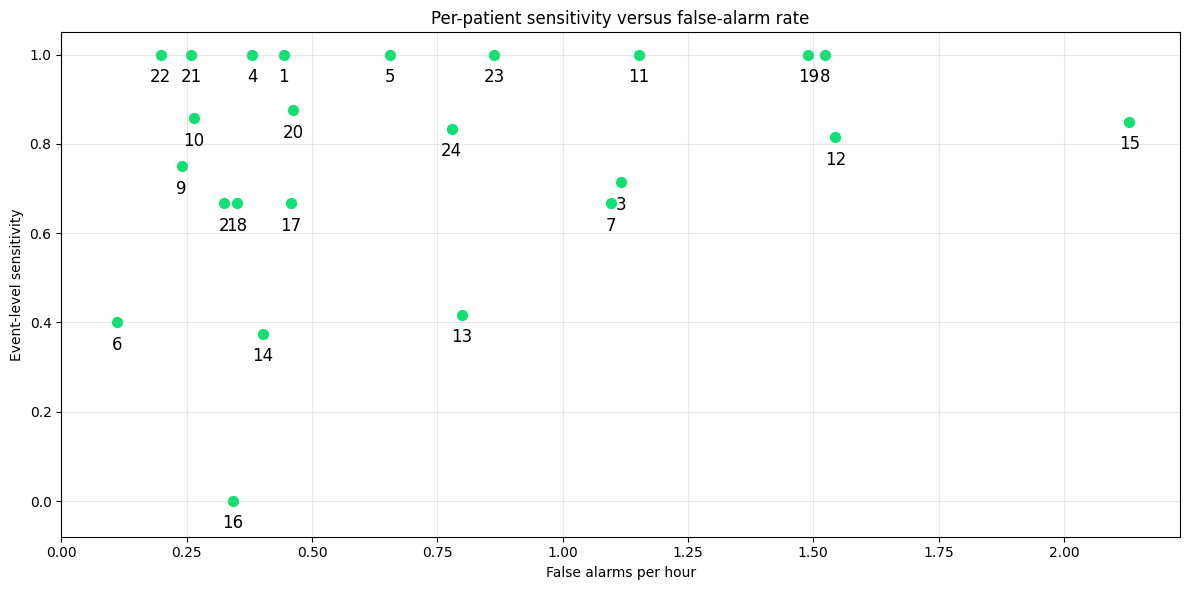

In [10]:
import matplotlib.pyplot as plt

# One row per patient
df = (
    results
    .drop_duplicates("patient")
    .sort_values("patient")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df["FP/hour"],
    df["sensitivity"],
    s=50,
    color=GREEN,
)

# Label each point
for _, row in df.iterrows():
    label = str(int(row["patient"].replace("chb", "")))

    ax.text(
        row["FP/hour"],
        row["sensitivity"] - 0.03,
        label,
        fontsize=12,
        ha="center",
        va="top"
    )
ax.set_xlabel("False alarms per hour")
ax.set_ylabel("Event-level sensitivity")
ax.set_title("Per-patient sensitivity versus false-alarm rate")

ax.set_xlim(left=0)
ax.set_ylim(-0.08, 1.05)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Missed events

In [11]:
GREEN

'#0fe071'

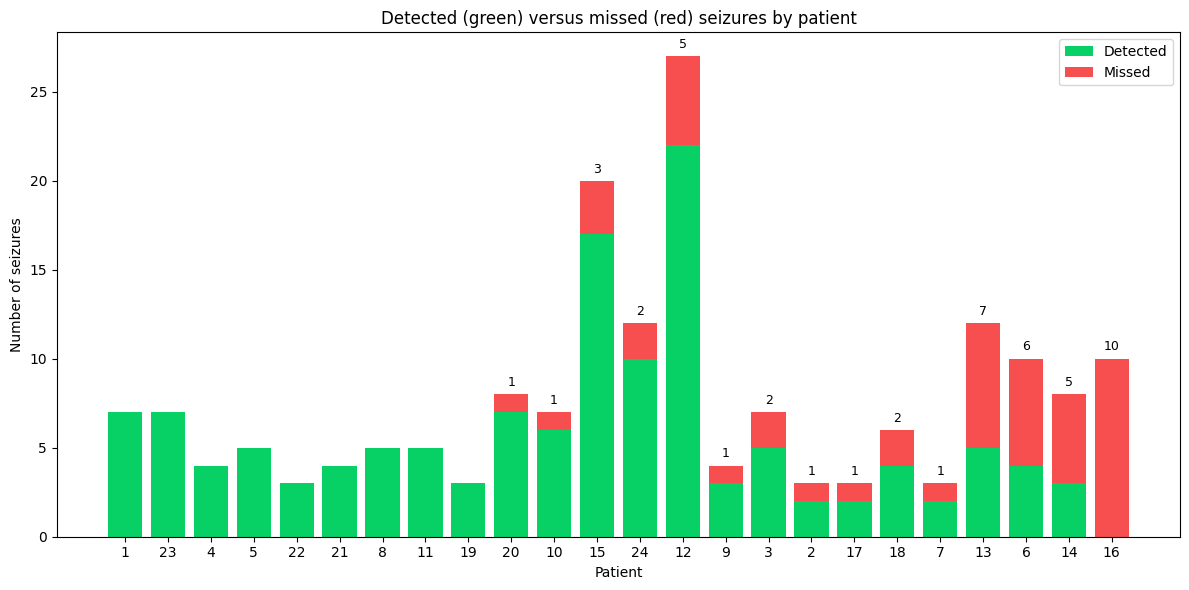

In [12]:
import matplotlib.pyplot as plt

# ----------------------------------
# Prepare data
# ----------------------------------
df = (
    results[["patient", "TP", "FN", "sensitivity"]]
    .drop_duplicates("patient") 
    .sort_values("sensitivity", ascending=False)
    .reset_index(drop=True)
)

# Patient labels as numbers only
labels = df["patient"].str.replace("chb", "", regex=False).str.lstrip("0")

fig, ax = plt.subplots(figsize=(12, 6))

# Detected seizures
ax.bar( 
    labels,
    df["TP"],
    color="#07d065",
    label="Detected"
)

# Missed seizures (stacked)
ax.bar(
    labels,
    df["FN"],
    bottom=df["TP"],
    color="#F74F4F",
    label="Missed"
)

# Miss count above each bar
for i, row in enumerate(df.itertuples()):
    if row.FN > 0:
        ax.text(
            i,
            row.TP + row.FN + 0.3,
            str(int(row.FN)),
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xlabel("Patient")
ax.set_ylabel("Number of seizures")
ax.set_title("Detected (green) versus missed (red) seizures by patient")
ax.legend()

plt.tight_layout()
plt.show()

## False alarms

In [13]:
GREEN

'#0fe071'

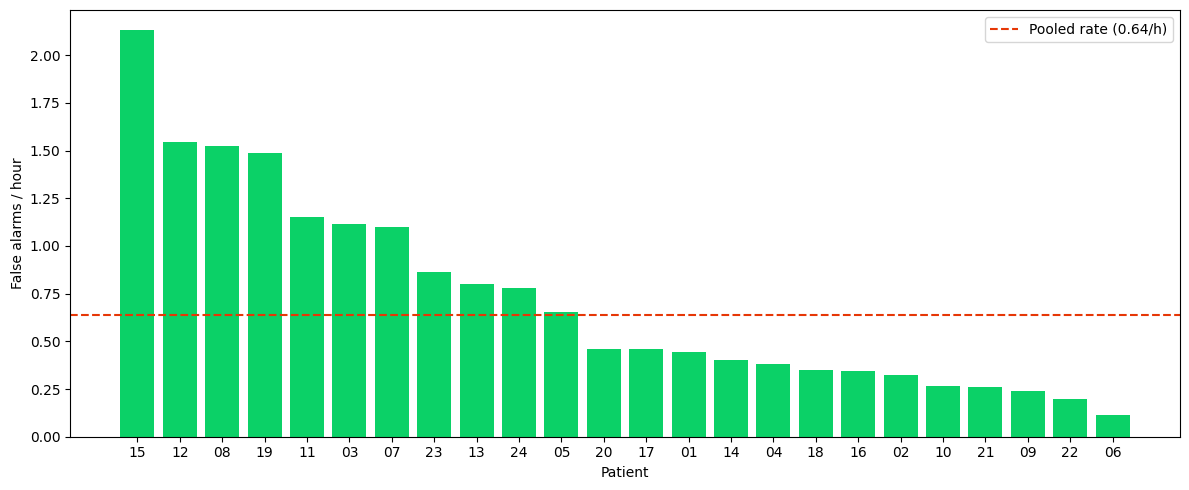

In [24]:
import matplotlib.pyplot as plt

# Sort by false alarm rate
fp_plot = (
    results
    .drop_duplicates("patient")
    .sort_values("FP/hour", ascending=False)
    .copy()
)

# Numeric patient labels (1-24 instead of chb01 etc.)
fp_plot["patient_label"] = (
    fp_plot["patient"]
    .str.replace("chb", "")
)

fig, ax = plt.subplots(figsize=(12,5))

ax.bar(
    fp_plot["patient_label"],
    fp_plot["FP/hour"],
    color="#0bd167"
)

# pooled false alarm rate
pooled_fp_rate = 0.64

ax.axhline(
    pooled_fp_rate,
    linestyle="--",
     color="#E63706", 
    label=f"Pooled rate ({pooled_fp_rate:.2f}/h)"
)


ax.set_xlabel("Patient")
ax.set_ylabel("False alarms / hour")

ax.legend()

plt.tight_layout()
plt.show()

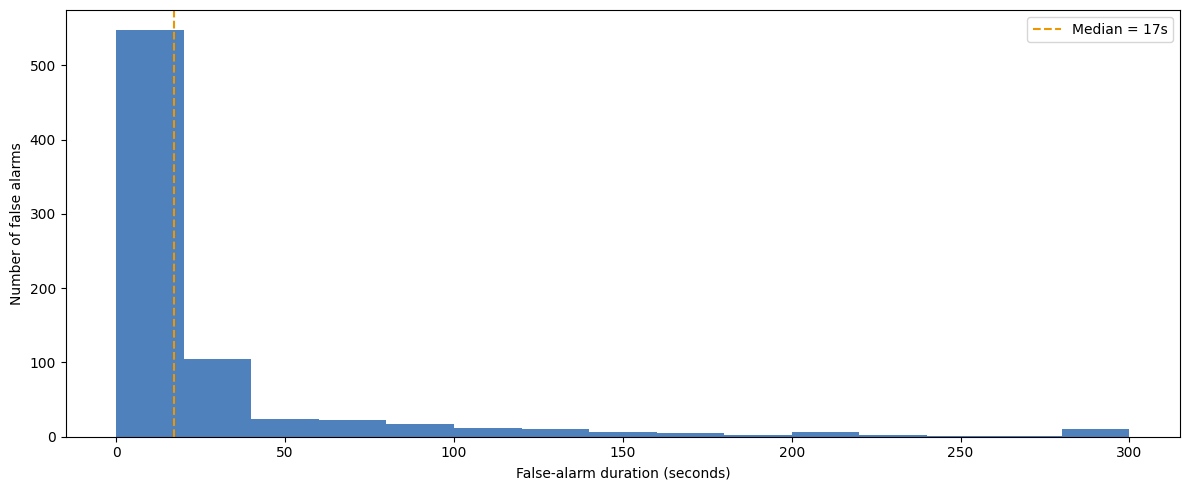

In [30]:
import matplotlib.pyplot as plt
import numpy as np

durations = false_positives["fp_duration_s"]

fig, ax = plt.subplots(figsize=(12,5))

ax.hist(
    durations,
    bins=np.arange(0, 310, 20),   # 10-second bins
    color=BLUE,
)

ax.axvline(
    durations.median(),
    linestyle="--",
     color="#ED9600", 
    label=f"Median = {durations.median():.0f}s"
)

ax.set_xlabel("False-alarm duration (seconds)")
ax.set_ylabel("Number of false alarms")

ax.legend()

plt.tight_layout()
plt.show()

## Precison vs. Sensitivity

In [33]:
results.columns

Index(['C', 'gamma', 'k_feat', 'patient', 'total_length_hours', 'TP', 'FP',
       'FN', 'sensitivity', 'precision', 'f1', 'sample_TP', 'sample_FP',
       'sample_FN', 'sample_sensitivity', 'sample_precision', 'sample_f1',
       'FP/day', 'FP/hour', 'latency_median', 'n_detected',
       'mean_fold_roc_auc', 'mean_fold_ap', 'sens_k2', 'f1_k2', 'fpday_k2',
       'sens_k3', 'f1_k3', 'fpday_k3', 'sens_k4', 'f1_k4', 'fpday_k4'],
      dtype='object')

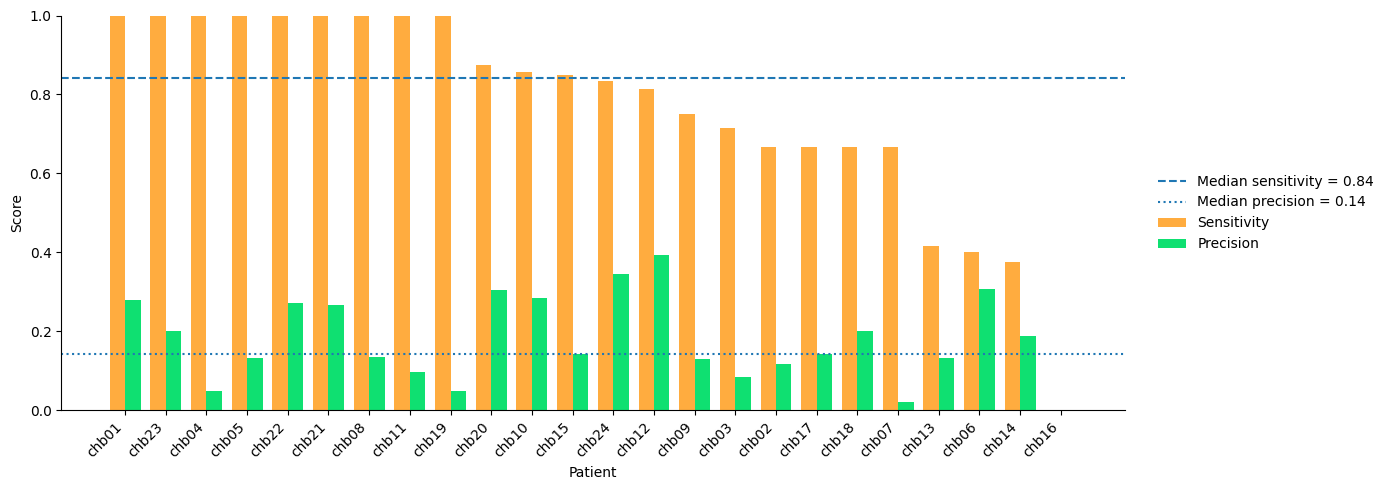

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Order by descending sensitivity
df = (
    results
    .sort_values("sensitivity", ascending=False)
    .reset_index(drop=True)
)

x = np.arange(len(df))
width = 0.38

median_sens = df["sensitivity"].median()
median_prec = df["precision"].median()

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    x - width/2,
    df["sensitivity"],
    width,
    color="#FFAC3F",
    label="Sensitivity")

ax.bar(
    x + width/2,
    df["precision"],
    width,
    color=GREEN,
    label="Precision")

# Median lines
ax.axhline(
    median_sens,
    linestyle="--",
    linewidth=1.5,
    label=f"Median sensitivity = {median_sens:.2f}"
)

ax.axhline(
    median_prec,
    linestyle=":",
    linewidth=1.5,
    label=f"Median precision = {median_prec:.2f}"
)

ax.set_xticks(x)
ax.set_xticklabels(df["patient"], rotation=45, ha="right")
ax.set_ylim(0, 1)

ax.set_xlabel("Patient")
ax.set_ylabel("Score")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

## K=3

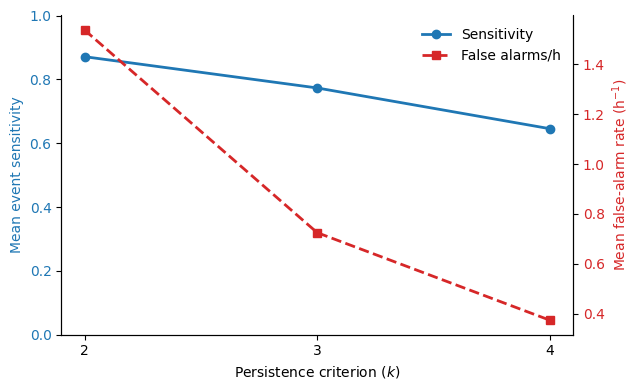

In [53]:
import matplotlib.pyplot as plt

# Mean across patients
k = [2, 3, 4]

mean_sens = [
    results["sens_k2"].mean(),
    results["sens_k3"].mean(),
    results["sens_k4"].mean(),
]

# Convert FP/day to FP/hour
mean_fphour = [
    results["fpday_k2"].mean() / 24,
    results["fpday_k3"].mean() / 24,
    results["fpday_k4"].mean() / 24,
]

fig, ax1 = plt.subplots(figsize=(6.5, 4))

# Sensitivity (blue)
line1 = ax1.plot(
    k,
    mean_sens,
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Sensitivity"
)

ax1.set_xlabel("Persistence criterion ($k$)")
ax1.set_ylabel("Mean event sensitivity", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(k)
ax1.set_ylim(0, 1)

# False alarms/hour (red)
ax2 = ax1.twinx()

line2 = ax2.plot(
    k,
    mean_fphour,
    marker="s",
    linestyle="--",
    linewidth=2,
    color="tab:red",
    label="False alarms/h"
)

ax2.set_ylabel("Mean false-alarm rate (h$^{-1}$)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Clean style
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

## Comparison

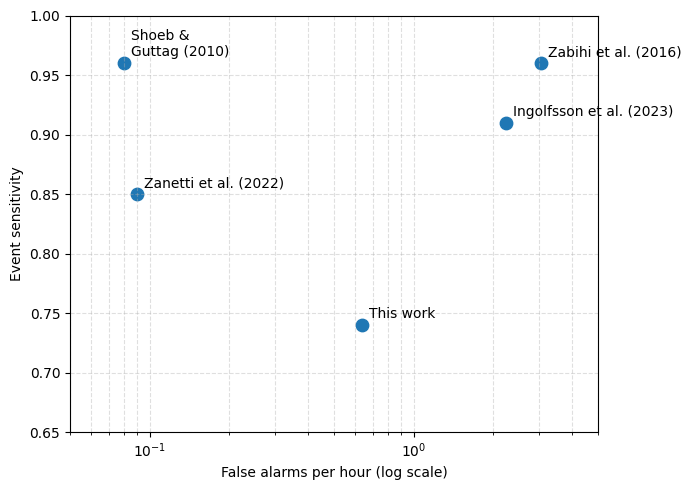

In [3]:
import matplotlib.pyplot as plt

# Data
studies = [
    "This work",
    "Shoeb &\nGuttag (2010)",
    "Zabihi et al. (2016)",
    "Zanetti et al. (2022)",
    "Ingolfsson et al. (2023)"
]

sensitivity = [0.74, 0.96, 0.96, 0.85, 0.91]
fa_per_hour = [0.64, 0.08, 3.04, 0.09, 2.24]

fig, ax = plt.subplots(figsize=(7, 5))

# Scatter points
ax.scatter(fa_per_hour, sensitivity, s=80)

# Labels
for x, y, label in zip(fa_per_hour, sensitivity, studies):
    ax.annotate(
        label,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10
    )

# Axes
ax.set_xscale("log")
ax.set_xlabel("False alarms per hour (log scale)")
ax.set_ylabel("Event sensitivity")
ax.set_xlim(0.05, 5)
ax.set_ylim(0.65, 1.0)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

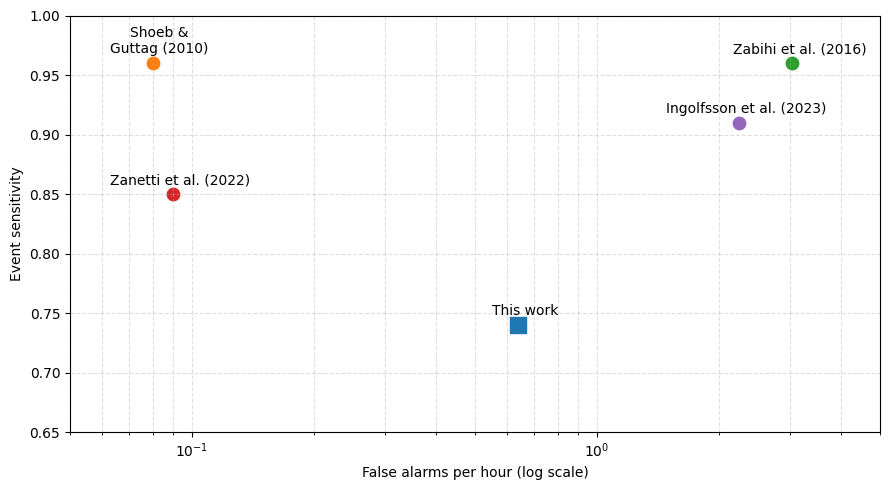

In [12]:
markers = ["s", "o", "o", "o", "o"]
sizes = [120, 80, 80, 80, 80]

fig, ax = plt.subplots(figsize=(9,5))

for x, y, m, s in zip(fa_per_hour, sensitivity, markers, sizes):
    ax.scatter(x, y, marker=m, s=s)

for x, y, label in zip(fa_per_hour, sensitivity, studies):
    ax.annotate(label, (x, y),
                xytext=(5,5),
                textcoords="offset points",
        ha="center",            # horizontally center
        va="bottom",
                fontsize=10)

ax.set_xscale("log")
ax.set_xlabel("False alarms per hour (log scale)")
ax.set_ylabel("Event sensitivity")
ax.set_xlim(0.05, 5)
ax.set_ylim(0.65, 1.0)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()